In [ ]:
import torch
from pathlib import Path
import os
%matplotlib inline
import matplotlib.pyplot as plt

notebook_dir = Path().absolute()
if notebook_dir.name == 'examples':
    os.chdir(notebook_dir.parent)

from src.models import CoupledHopfModel, NeuralSDE
from src.dataset import NeuroscienceDataset, compute_omega_from_timeseries

In [ ]:
dataset = NeuroscienceDataset(filepath="data/ts_young/ts_young_TR0.72.mat", normalize=True, max_subjects=2, fourier_denoise=True)
omega = compute_omega_from_timeseries(dataset.timeseries, dt=dataset.dt, f_lo=0.04, f_hi=0.07, method="peak")

In [ ]:
n_steps = 50
# Create a Coupled Hopf model for 68 ROIs (e.g., Desikan-Killiany atlas)
model = CoupledHopfModel(
    n_rois=100,
    initial_a=-0.02,  # Bifurcation parameter (near criticality)
    initial_g=1.6,    # Global coupling strength
    noise_sigma=0.1,
    omega=omega,
    structural_connectivity=dataset.fc_mean,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

# Simulate 200 timepoints
with torch.no_grad():
    timeseries = model.forward(initial_state=dataset.timeseries[:, :, 0], n_steps=n_steps)  # (1, 100, 20) complex
    fc_matrix = model.compute_fc(timeseries)                 # (1, 100, 100)

print(f"Simulated timeseries shape: {timeseries.shape}")
print(f"FC matrix shape: {fc_matrix.shape}")

Simulated timeseries shape: torch.Size([2, 100, 50])
FC matrix shape: torch.Size([2, 100, 100])


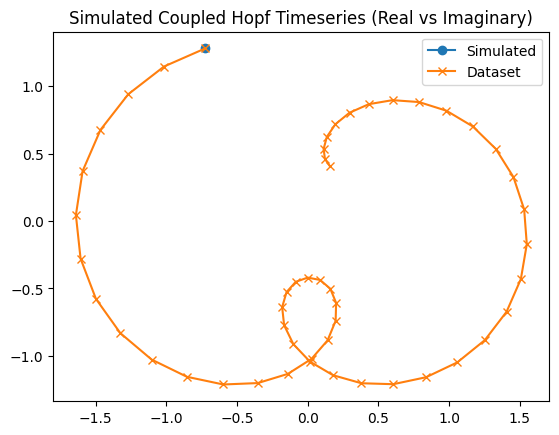

In [ ]:
plt.plot(timeseries[0,0].real, timeseries[0,0].imag, marker='o', label='Simulated')
plt.plot(dataset.timeseries[0,0, :n_steps].real, dataset.timeseries[0,0, :n_steps].imag, marker='x', label='Dataset')
plt.title("Simulated Coupled Hopf Timeseries (Real vs Imaginary)")
plt.legend()
plt.show()

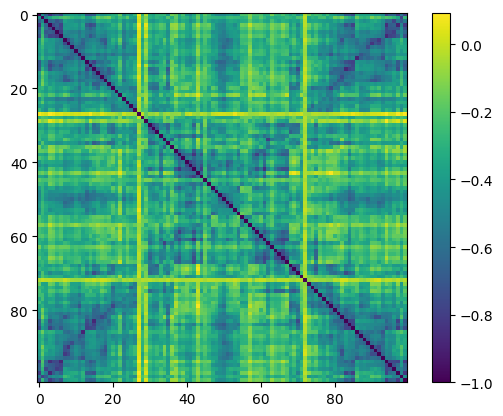

In [ ]:
plt.imshow(dataset.fc_mean, cmap='viridis')
plt.colorbar()